# Data Preparation Module

**Dataset:** Amod/mental_health_counseling_conversations 

**Goal:** Produce a clean, enriched, export-ready dataset before any embedding or indexing begins




## 1. Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib     import Path
from collections import Counter
from datasets    import load_dataset

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = Path('../module_4_rag')
OUTPUT_DIR.mkdir(exist_ok = True)

PLOTS_DIR = OUTPUT_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok = True)

plt.rcParams.update({
    'figure.dpi'        : 130,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'font.family'       : 'DejaVu Sans'
})

BLUE   = '#4C72B0'
GREEN  = '#55A868'
RED    = '#C44E52'
ORANGE = '#DD8452'
PURPLE = '#8172B2'

print('Environment ready')
print(f'Output dir : {OUTPUT_DIR.resolve()}')
print(f'Plots dir  : {PLOTS_DIR.resolve()}')

Environment ready
Output dir : C:\Users\WellCome\Desktop\Mental_Health_System\module_4_rag
Plots dir  : C:\Users\WellCome\Desktop\Mental_Health_System\module_4_rag\plots


## 2. Dataset Loading

Loading the raw dataset from HuggingFace and doing a first inspection  
before any transformation is applied.

In [2]:
raw = load_dataset('Amod/mental_health_counseling_conversations')
df  = raw['train'].to_pandas()

print(f'Shape          : {df.shape}')
print(f'Columns        : {list(df.columns)}')
print(f'Memory usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
print('Dtypes:')
print(df.dtypes.to_string())
print()
print('Null counts:')
print(df.isnull().sum().to_string())

README.md: 0.00B [00:00, ?B/s]

combined_dataset.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/3512 [00:00<?, ? examples/s]

Shape          : (3512, 2)
Columns        : ['Context', 'Response']
Memory usage   : 4561.9 KB

Dtypes:
Context     str
Response    str

Null counts:
Context     0
Response    0


In [3]:
print('Sample rows\n')
for i in range(3):
    row = df.iloc[i]
    print(f'Row {i}')
    print(f'  Context  : {row["Context"][:150]}...')
    print(f'  Response : {row["Response"][:150]}...')
    print()

Sample rows

Row 0
  Context  : I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be he...
  Response : If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is ...

Row 1
  Context  : I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be he...
  Response : Hello, and thank you for your question and seeking advice on this. Feelings of worthlessness is unfortunately common. In fact, most people, if not all...

Row 2
  Context  : I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be he...
  Response : First thing I'd suggest is getting the sleep you need or it will impact how you think and feel. I'd look at finding wha

## 3. Exploratory Data Analysis

Understanding the data structure, length distributions, and key quality signals  
before making any preprocessing decisions.

### 3.1 Basic Statistics

In [4]:
df['context_len']    = df['Context'].str.len()
df['response_len']   = df['Response'].str.len()
df['context_words']  = df['Context'].str.split().str.len()
df['response_words'] = df['Response'].str.split().str.len()

stats = pd.DataFrame({
    'context_chars'  : df['context_len'].describe(),
    'response_chars' : df['response_len'].describe(),
    'context_words'  : df['context_words'].describe(),
    'response_words' : df['response_words'].describe()
}).round(1)

print('Text length statistics:')
print(stats.to_string())
print()
print(f'Very short contexts  (< 20 chars)  : {(df["context_len"]  < 20).sum()}')
print(f'Very short responses (< 30 chars)  : {(df["response_len"] < 30).sum()}')
print(f'Very long responses  (> 3000 chars) : {(df["response_len"] > 3000).sum()}')

Text length statistics:
       context_chars  response_chars  context_words  response_words
count         3512.0          3512.0         3512.0          3512.0
mean           282.7          1026.1           55.2           177.0
std            246.2          1010.8           48.3           120.7
min             25.0             0.0            5.0             0.0
25%            147.0           532.0           28.0            93.0
50%            232.0           836.0           46.0           144.0
75%            348.2          1271.8           68.0           221.0
max           2703.0         32739.0          526.0           939.0

Very short contexts  (< 20 chars)  : 0
Very short responses (< 30 chars)  : 9
Very long responses  (> 3000 chars) : 72


### 3.2 Length Distributions

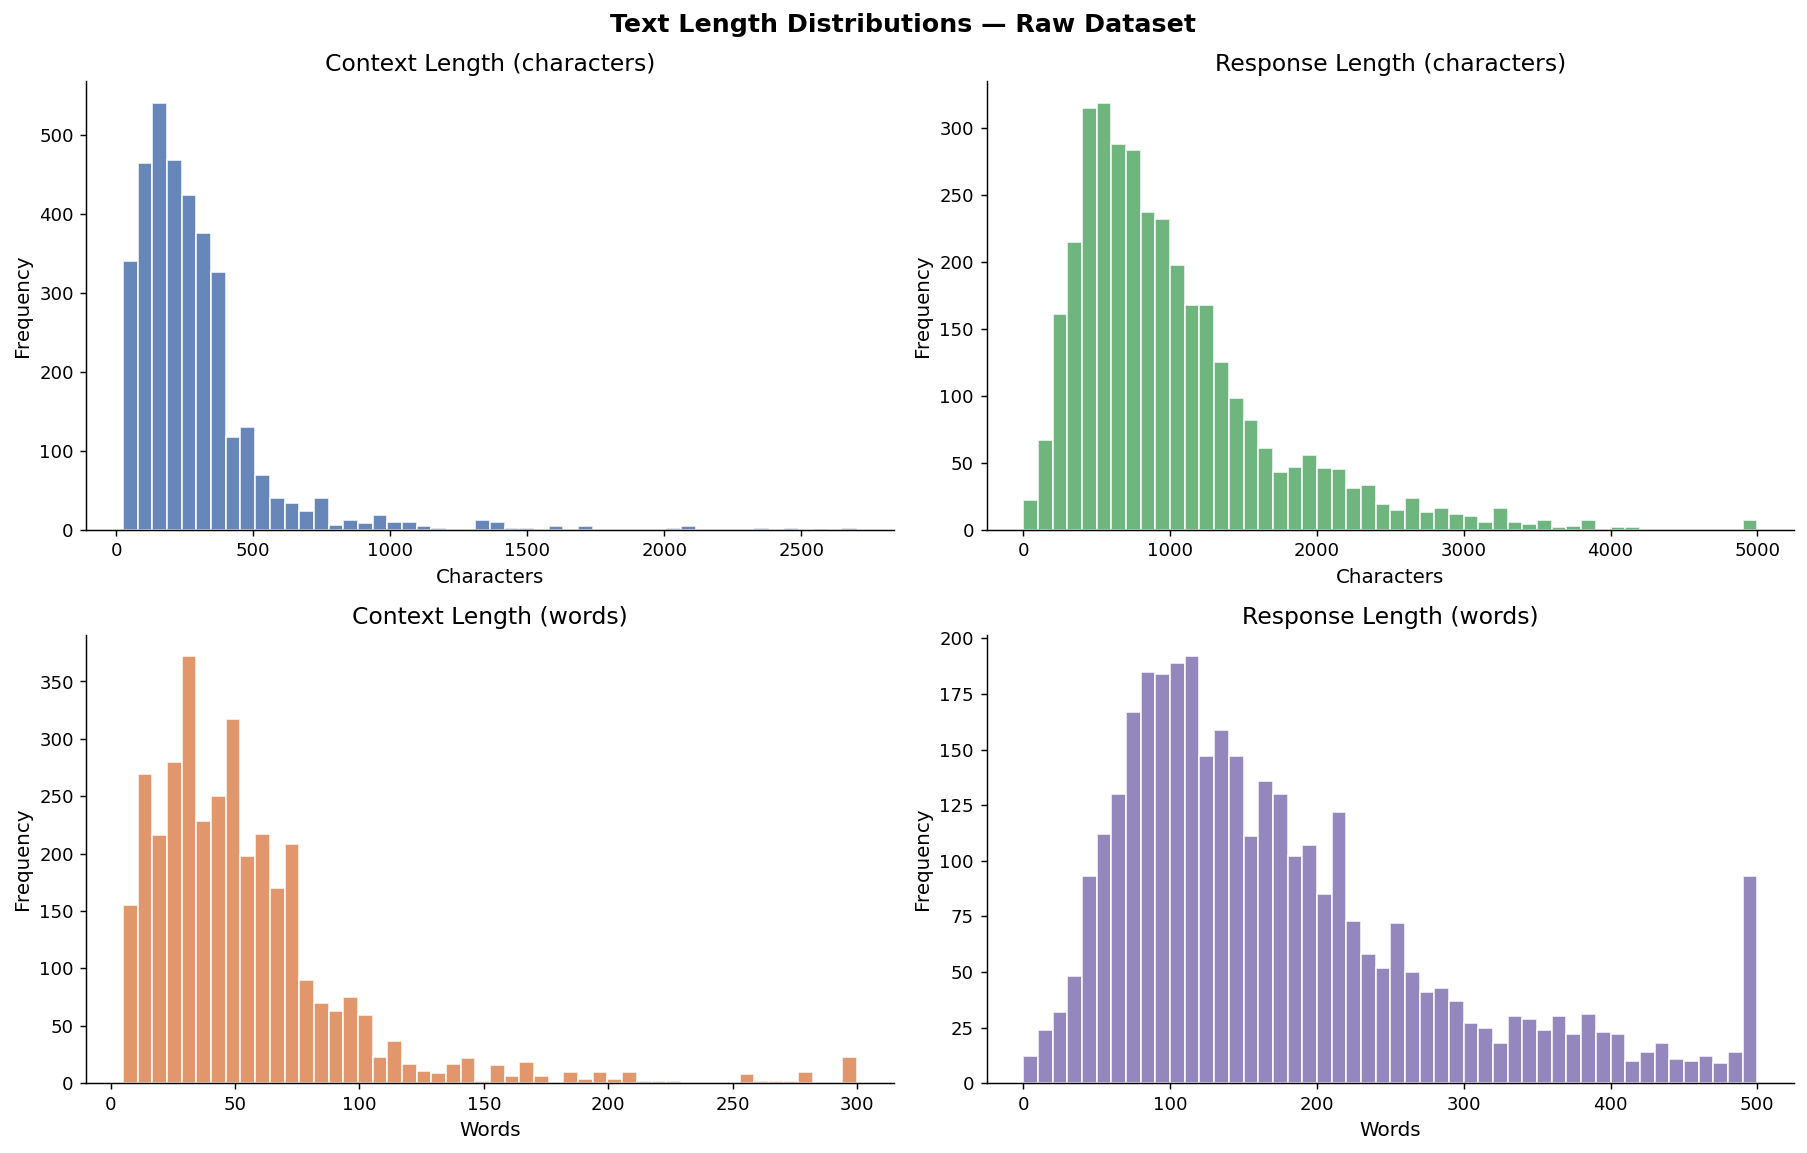

In [5]:
fig, axes = plt.subplots(2, 2, figsize = (14, 9))

axes[0, 0].hist(df['context_len'].clip(upper = 3000), bins = 50,
                color = BLUE, edgecolor = 'white', alpha = 0.85)
axes[0, 0].set_title('Context Length (characters)')
axes[0, 0].set_xlabel('Characters')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(df['response_len'].clip(upper = 5000), bins = 50,
                color = GREEN, edgecolor = 'white', alpha = 0.85)
axes[0, 1].set_title('Response Length (characters)')
axes[0, 1].set_xlabel('Characters')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(df['context_words'].clip(upper = 300), bins = 50,
                color = ORANGE, edgecolor = 'white', alpha = 0.85)
axes[1, 0].set_title('Context Length (words)')
axes[1, 0].set_xlabel('Words')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(df['response_words'].clip(upper = 500), bins = 50,
                color = PURPLE, edgecolor = 'white', alpha = 0.85)
axes[1, 1].set_title('Response Length (words)')
axes[1, 1].set_xlabel('Words')
axes[1, 1].set_ylabel('Frequency')

plt.suptitle('Text Length Distributions — Raw Dataset', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_01_length_distributions.png', bbox_inches = 'tight')
plt.show()

### 3.3 Redundancy (Contexts with Multiple Responses)

In [6]:
context_counts     = df['Context'].value_counts()
unique_contexts    = df['Context'].nunique()
total_rows         = len(df)
redundancy_ratio   = total_rows / unique_contexts

print(f'Total rows                         : {total_rows:,}')
print(f'Unique contexts                    : {unique_contexts:,}')
print(f'Average responses per context      : {redundancy_ratio:.2f}x')
print(f'Max responses for one context      : {context_counts.max()}')
print(f'Contexts with only 1 response      : {(context_counts == 1).sum():,}')
print(f'Contexts with 5+ responses         : {(context_counts >= 5).sum():,}')
print(f'Contexts with 10+ responses        : {(context_counts >= 10).sum():,}')
print()

response_dist = context_counts.value_counts().sort_index()
print('Responses per context distribution:')
for n_resp, n_ctx in response_dist.items():
    bar = '█' * int(n_ctx / response_dist.max() * 28)
    print(f'  {n_resp:>3} response(s) : {n_ctx:>4} contexts  {bar}')

Total rows                         : 3,512
Unique contexts                    : 995
Average responses per context      : 3.53x
Max responses for one context      : 94
Contexts with only 1 response      : 236
Contexts with 5+ responses         : 181
Contexts with 10+ responses        : 45

Responses per context distribution:
    1 response(s) :  236 contexts  ██████████████████
    2 response(s) :  361 contexts  ████████████████████████████
    3 response(s) :   90 contexts  ██████
    4 response(s) :  127 contexts  █████████
    5 response(s) :   36 contexts  ██
    6 response(s) :   49 contexts  ███
    7 response(s) :   17 contexts  █
    8 response(s) :   19 contexts  █
    9 response(s) :   15 contexts  █
   10 response(s) :    7 contexts  
   11 response(s) :    7 contexts  
   12 response(s) :    5 contexts  
   13 response(s) :    3 contexts  
   14 response(s) :    1 contexts  
   15 response(s) :    4 contexts  
   16 response(s) :    2 contexts  
   17 response(s) :    3 cont

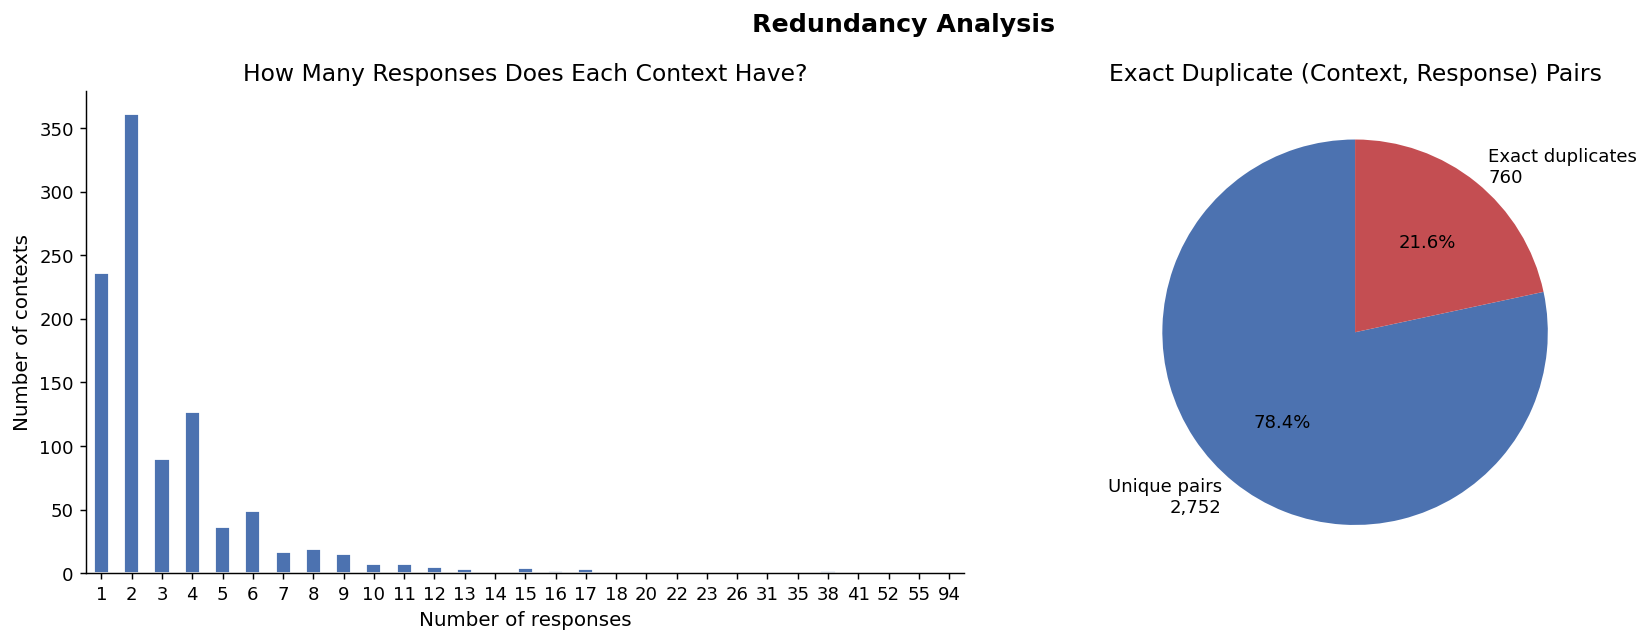

In [7]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Left: bar chart of response count distribution
response_dist.plot(kind = 'bar', ax = axes[0], color = BLUE, edgecolor = 'white')
axes[0].set_title('How Many Responses Does Each Context Have?')
axes[0].set_xlabel('Number of responses')
axes[0].set_ylabel('Number of contexts')
axes[0].tick_params(axis = 'x', rotation = 0)



# Right: pie of unique vs redundant rows
n_unique_pairs = df.drop_duplicates(subset = ['Context', 'Response']).shape[0]
n_exact_dupes  = total_rows - n_unique_pairs
axes[1].pie(
    [n_unique_pairs, n_exact_dupes],
    labels     = [f'Unique pairs\n{n_unique_pairs:,}', f'Exact duplicates\n{n_exact_dupes:,}'],
    colors     = [BLUE, RED],
    startangle = 90,
    autopct    = '%1.1f%%',
    textprops  = {'fontsize': 10}
)
axes[1].set_title('Exact Duplicate (Context, Response) Pairs')

plt.suptitle('Redundancy Analysis', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_02_redundancy.png', bbox_inches = 'tight')
plt.show()

## 4. Data Cleaning

Fixing all structural issues found in EDA before any analysis or enrichment.

**Issues addressed:**
- HTML tags and entities embedded in text
- Control characters and non-printable unicode
- Excessive whitespace and inconsistent newlines
- Null / empty rows
- Exact duplicate (context, response) pairs
- Near-empty texts below minimum length threshold

In [8]:
def clean_text(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''
    
    text = re.sub(r'<[^>]+>', ' ', text)                # strip HTML tags
    text = re.sub(r'&[a-zA-Z]+;', ' ', text)            # strip HTML entities
    text = re.sub(r'[\x00-\x08\x0b-\x1f\x7f]', '', text)  # control chars
    text = re.sub(r'[ \t]+', ' ', text)                 # collapse spaces/tabs
    text = re.sub(r'\n{3,}', '\n\n', text)              # max 2 consecutive newlines
    return text.strip()

In [9]:
n_before = len(df)

df['Context']  = df['Context'].apply(clean_text)
df['Response'] = df['Response'].apply(clean_text)

# Recompute lengths after cleaning
df['context_len']  = df['Context'].str.len()
df['response_len'] = df['Response'].str.len()

In [ ]:
# Drop null / empty
df = df[(df['Context'] != '') & (df['Response'] != '')].reset_index(drop = True)
print(f'After removing empty texts     : {len(df):,}  (removed {n_before - len(df):,})')

# Drop exact (context, response) duplicates
n_before = len(df)
df = df.drop_duplicates(subset = ['Context', 'Response']).reset_index(drop = True)
print(f'After dropping exact dupes     : {len(df):,}  (removed {n_before - len(df):,})')

# Drop near-empty texts below minimum thresholds
n_before = len(df)
df = df[(df['context_len'] >= 20) & (df['response_len'] >= 30)].reset_index(drop = True)
print(f'After dropping near-empty texts: {len(df):,}  (removed {n_before - len(df):,})')
print()

print('Recomputing word counts after cleaning')
df['context_words']  = df['Context'].str.split().str.len()
df['response_words'] = df['Response'].str.split().str.len()
print('Done')

After removing empty texts     : 3,508  (removed 4)
After dropping exact dupes     : 2,278  (removed 1,230)
After dropping near-empty texts: 2,275  (removed 3)

Recomputing word counts after cleaning...
Done


## 5. Semantic Redundancy Analysis

After removing exact duplicates there is still structural redundancy:  
the same Context appears with multiple different responses from different therapists  

**Strategy:**
for each unique context keep the single best response "Best" is defined by a quality score built from three proxy signals:

- **Empathy signal** does the response acknowledge the user's feelings?
- **Actionable advice** does it offer something concrete to try?
- **Sufficient length** is it long enough to be genuinely helpful?

Tie-breaking by response length ensures we keep the most detailed answer

In [11]:
EMPATHY_SIGNALS = [
    'i understand', 'i hear you', 'i can imagine', 'that must be',
    'i am sorry', "i'm sorry", 'it sounds like', 'it makes sense',
    'you are not alone', "you're not alone", 'thank you for sharing',
    'that takes courage', 'i want you to know', 'it is okay to feel',
    'your feelings are', 'i can see', 'that is really hard'
]

ACTIONABLE_SIGNALS = [
    'i would suggest', 'i recommend', 'one thing you can', 'try to',
    'consider', 'it may help', 'it can help', 'a therapist',
    'counseling', 'therapy', 'speaking with', 'reach out',
    'you might want to', 'one step', 'a helpful approach',
    'breathing', 'journaling', 'mindfulness', 'grounding'
]


In [12]:
resp_lower = df['Response'].str.lower()
df['has_empathy']    = resp_lower.apply(lambda x: any(s in x for s in EMPATHY_SIGNALS))
df['has_actionable'] = resp_lower.apply(lambda x: any(s in x for s in ACTIONABLE_SIGNALS))

df['is_long_enough'] = df['response_len'] >= 150
df['quality_score']  = (df['has_empathy'].astype(int) + df['has_actionable'].astype(int)  + df['is_long_enough'].astype(int))

print('Quality score distribution (before context deduplication):')
for score in range(4):
    count = (df['quality_score'] == score).sum()
    pct   = count / len(df) * 100
    bar   = '█' * int(pct)
    print(f'  Score {score} : {count:>4} ({pct:.1f}%)  {bar}')

Quality score distribution (before context deduplication):
  Score 0 :   20 (0.9%)  
  Score 1 :  868 (38.2%)  ██████████████████████████████████████
  Score 2 : 1123 (49.4%)  █████████████████████████████████████████████████
  Score 3 :  264 (11.6%)  ███████████


In [13]:
# For each unique context keep the response with the highest quality score
# Tie-break: longest response
n_before = len(df)

df = (
    df.sort_values(['quality_score', 'response_len'], ascending = [False, False])
      .drop_duplicates(subset = ['Context'], keep = 'first')
      .reset_index(drop = True)
)

print(f'Before context deduplication : {n_before:,}')
print(f'After context deduplication  : {len(df):,}  (kept best response per context)')
print()
print('Quality score distribution (after context deduplication):')
for score in range(4):
    count = (df['quality_score'] == score).sum()
    pct   = count / len(df) * 100
    bar   = '█' * int(pct)
    print(f'  Score {score} : {count:>4} ({pct:.1f}%)  {bar}')

Before context deduplication : 2,275
After context deduplication  : 938  (kept best response per context)

Quality score distribution (after context deduplication):
  Score 0 :    3 (0.3%)  
  Score 1 :  271 (28.9%)  ████████████████████████████
  Score 2 :  449 (47.9%)  ███████████████████████████████████████████████
  Score 3 :  215 (22.9%)  ██████████████████████


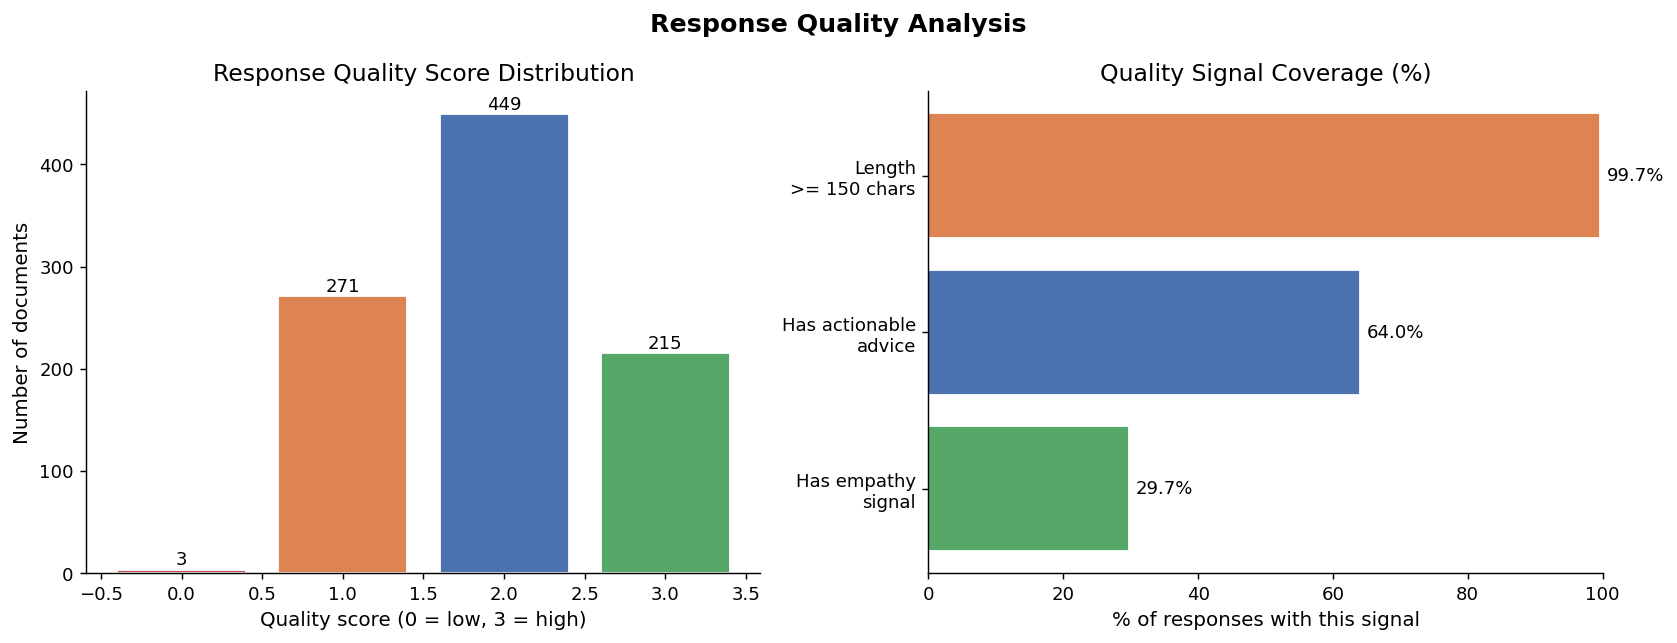

In [14]:
fig, axes = plt.subplots(1, 2, figsize = (13, 5))

# Left: quality score distribution
score_counts = df['quality_score'].value_counts().sort_index()
colors_q = [RED, ORANGE, BLUE, GREEN]
axes[0].bar(score_counts.index, score_counts.values,
            color = [colors_q[i] for i in score_counts.index], edgecolor = 'white')
axes[0].set_title('Response Quality Score Distribution')
axes[0].set_xlabel('Quality score (0 = low, 3 = high)')
axes[0].set_ylabel('Number of documents')
for x, y in zip(score_counts.index, score_counts.values):
    axes[0].text(x, y + 5, str(y), ha = 'center', fontsize = 10)

# Right: signal breakdown
signals = {
    'Has empathy\nsignal'    : df['has_empathy'].mean(),
    'Has actionable\nadvice' : df['has_actionable'].mean(),
    'Length\n>= 150 chars'   : df['is_long_enough'].mean()
}
axes[1].barh(list(signals.keys()), [v * 100 for v in signals.values()],
             color = [GREEN, BLUE, ORANGE], edgecolor = 'white')
axes[1].set_title('Quality Signal Coverage (%)')
axes[1].set_xlabel('% of responses with this signal')
axes[1].set_xlim(0, 100)
for i, v in enumerate(signals.values()):
    axes[1].text(v * 100 + 1, i, f'{v*100:.1f}%', va = 'center', fontsize = 10)

plt.suptitle('Response Quality Analysis', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_03_quality.png', bbox_inches = 'tight')
plt.show()

## 6. Topic Analysis

Tagging each document with the mental health topics it covers.  
Topics are detected from both the context and the response using a keyword dictionary.  
One document can carry multiple topic tags.

In [15]:
TOPIC_KEYWORDS = {
    'anxiety'        : ['anxiety', 'anxious', 'panic', 'panic attack', 'worry',
                        'worried', 'nervou', 'dread', 'apprehens'],

    'depression'     : ['depress', 'hopeless', 'worthless', 'empty inside',
                        'numb', 'meaningless', 'no motivation', 'can not get up'],

    'trauma_ptsd'    : ['trauma', 'ptsd', 'abuse', 'assault', 'flashback',
                        'nightmare', 'sexual abuse', 'domestic'],

    'relationships'  : ['relationship', 'marriage', 'partner', 'divorce',
                        'breakup', 'spouse', 'boyfriend', 'girlfriend',
                        'husband', 'wife', 'family conflict'],

    'self_harm'      : ['self-harm', 'self harm', 'cutting', 'hurt myself',
                        'injure myself', 'burn myself'],
                        
    'suicidal'       : ['suicid', 'kill myself', 'end my life', 'want to die',
                        'not want to live', 'better off dead', 'goodbye forever'],

    'sleep'          : ['sleep', 'insomnia', 'nightmares', 'cant sleep',
                        'tired', 'exhausted', 'fatigue'],

    'anger'          : ['anger', 'angry', 'rage', 'furious', 'frustrat',
                        'irritab', 'explosive', 'outburst'],

    'grief_loss'     : ['grief', 'griev', 'loss', 'lost someone', 'death',
                        'died', 'mourning', 'bereavement'],

    'self_esteem'    : ['self-esteem', 'self esteem', 'confidence', 'worthless',
                        'ugly', 'hate myself', 'not good enough', 'failure'],

    'stress'         : ['stress', 'overwhelm', 'burnout', 'pressure',
                        'overwork', 'too much', 'cant cope'],

    'addiction'      : ['addict', 'alcohol', 'drinking', 'drug', 'substance',
                        'porn', 'gambling', 'dependenc'],

    'eating_disorder': ['eating disorder', 'anorexia', 'bulimia', 'binge',
                        'purge', 'restrict eating', 'body image'],

    'loneliness'     : ['lonely', 'loneliness', 'isolated', 'no one cares',
                        'no friends', 'nobody understands', 'alone'],
}


In [16]:
def detect_topics(context: str, response: str) -> list:
    combined = (context + ' ' + response).lower()
    return [topic for topic, keywords in TOPIC_KEYWORDS.items()
            if any(kw in combined for kw in keywords)]


df['topics']   = df.apply(lambda r: detect_topics(r['Context'], r['Response']), axis = 1)
df['n_topics'] = df['topics'].str.len()

topic_counts = Counter(t for topics in df['topics'] for t in topics)

print('Topic distribution:')
for topic, count in sorted(topic_counts.items(), key = lambda x: -x[1]):
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  {topic:<20} : {count:>4}  ({pct:.1f}%)  {bar}')
print()
print(f'Documents with no detected topic : {(df["n_topics"] == 0).sum()}')
print(f'Mean topics per document         : {df["n_topics"].mean():.2f}')

Topic distribution:
  relationships        :  547  (58.3%)  █████████████████████████████
  anger                :  272  (29.0%)  ██████████████
  anxiety              :  217  (23.1%)  ███████████
  stress               :  211  (22.5%)  ███████████
  depression           :  204  (21.7%)  ██████████
  loneliness           :  141  (15.0%)  ███████
  trauma_ptsd          :  123  (13.1%)  ██████
  self_esteem          :  108  (11.5%)  █████
  sleep                :  101  (10.8%)  █████
  addiction            :   91  (9.7%)  ████
  grief_loss           :   70  (7.5%)  ███
  suicidal             :   32  (3.4%)  █
  self_harm            :   25  (2.7%)  █
  eating_disorder      :    9  (1.0%)  

Documents with no detected topic : 81
Mean topics per document         : 2.29


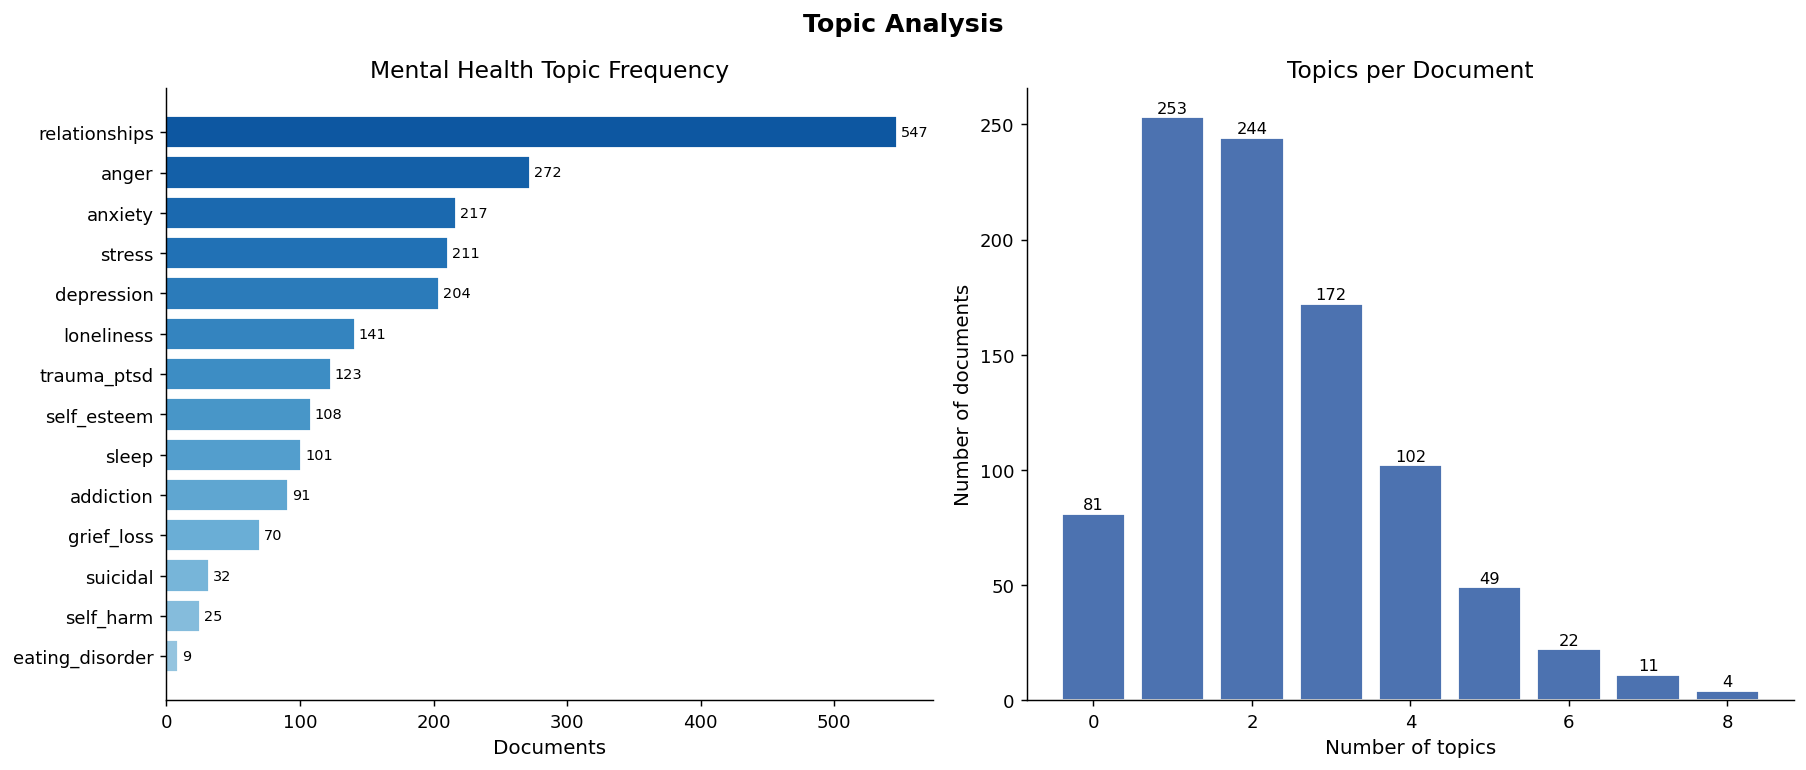

In [17]:
topic_df = pd.DataFrame(
    [(t, c) for t, c in sorted(topic_counts.items(), key = lambda x: x[1])],
    columns = ['topic', 'count']
)

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

# Left: topic frequency
bar_colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(topic_df)))
axes[0].barh(topic_df['topic'], topic_df['count'], color = bar_colors, edgecolor = 'white')
axes[0].set_title('Mental Health Topic Frequency')
axes[0].set_xlabel('Documents')
for i, row in enumerate(topic_df.itertuples()):
    axes[0].text(row.count + 3, i, str(row.count), va = 'center', fontsize = 8)

# Right: topics per document distribution
n_topics_dist = df['n_topics'].value_counts().sort_index()
axes[1].bar(n_topics_dist.index, n_topics_dist.values, color = BLUE, edgecolor = 'white')
axes[1].set_title('Topics per Document')
axes[1].set_xlabel('Number of topics')
axes[1].set_ylabel('Number of documents')
for x, y in zip(n_topics_dist.index, n_topics_dist.values):
    axes[1].text(x, y + 2, str(y), ha = 'center', fontsize = 9)

plt.suptitle('Topic Analysis', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_04_topics.png', bbox_inches = 'tight')
plt.show()

## 7. Risk Analysis

Assigning a clinical risk level to each document based on the content of the context.  
This label is stored as metadata and used at inference time to:

- Trigger the crisis override for any "crisis" document retrieved
- Prioritize empathetic tone for "high" risk documents
- Adjust the therapist LLM system prompt accordingly

**Risk levels:**


- crisis -->  Explicit suicidal ideation, self-harm or immediate danger 
- high   --> Severe depression, hopelessness, trauma, major distress 
- medium --> Anxiety, relationship problems, grief, moderate distress 
- low    --> General mental health questions, stress, mild concerns 

In [18]:
CRISIS_SIGNALS = [
    'kill myself', 'want to die', 'end my life', 'suicid',
    'not want to live', 'better off dead', 'goodbye forever',
    'no reason to live', 'rather be dead', 'take my own life',
    'planning to end', 'method to kill'
]

HIGH_RISK_SIGNALS = [
    'self-harm', 'self harm', 'cutting myself', 'hurt myself',
    'completely hopeless', 'worthless', 'severe depression',
    'cannot go on', "can't go on", 'abuse', 'assault',
    'trauma', 'ptsd', 'flashback', 'nobody cares',
    'no reason', 'nothing matters', 'feel like dying'
]

MEDIUM_RISK_SIGNALS = [
    'anxiety', 'anxious', 'panic attack', 'depression', 'depress',
    'grief', 'loss', 'divorce', 'breakup', 'relationship',
    'angry', 'rage', 'insomnia', 'overwhelmed', 'burnout',
    'lonely', 'isolated', 'addiction', 'eating disorder'
]

In [19]:
def assign_risk_level(context: str) -> str:
    ctx_lower = context.lower()
    if any(sig in ctx_lower for sig in CRISIS_SIGNALS):
        return 'crisis'
    if any(sig in ctx_lower for sig in HIGH_RISK_SIGNALS):
        return 'high'
    if any(sig in ctx_lower for sig in MEDIUM_RISK_SIGNALS):
        return 'medium'
    return 'low'


df['risk_level'] = df['Context'].apply(assign_risk_level)

risk_counts = df['risk_level'].value_counts()
risk_order  = ['crisis', 'high', 'medium', 'low']

print('Risk level distribution:')
for level in risk_order:
    count = risk_counts.get(level, 0)
    pct   = count / len(df) * 100
    bar   = '█' * int(pct / 2)
    print(f'  {level:<8} : {count:>4}  ({pct:.1f}%)  {bar}')

Risk level distribution:
  crisis   :   20  (2.1%)  █
  high     :   69  (7.4%)  ███
  medium   :  314  (33.5%)  ████████████████
  low      :  535  (57.0%)  ████████████████████████████


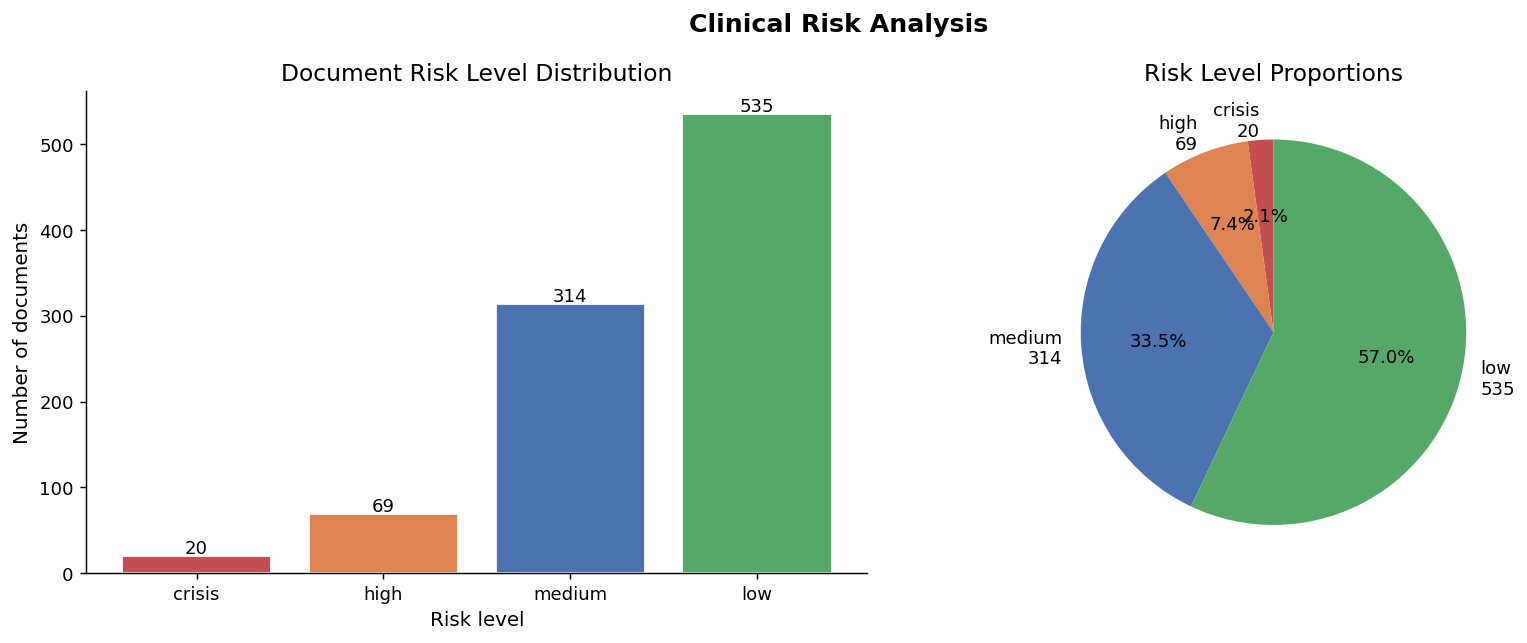

Crisis document sample:
  Context : I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think...

  Context : I am pretty sure I have depression and anxiety. I also have voices in my head. I have problems sleep...



In [20]:
fig, axes = plt.subplots(1, 2, figsize = (13, 5))

risk_colors = {'crisis': RED, 'high': ORANGE, 'medium': BLUE, 'low': GREEN}
risk_vals   = [risk_counts.get(r, 0) for r in risk_order]

# Left: bar chart
bars = axes[0].bar(
    risk_order, risk_vals,
    color = [risk_colors[r] for r in risk_order], edgecolor = 'white'
)
axes[0].set_title('Document Risk Level Distribution')
axes[0].set_xlabel('Risk level')
axes[0].set_ylabel('Number of documents')
for bar, val in zip(bars, risk_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 3,
                 str(val), ha = 'center', fontsize = 10)

# Right: pie chart
axes[1].pie(
    risk_vals,
    labels     = [f'{r}\n{v:,}' for r, v in zip(risk_order, risk_vals)],
    colors     = [risk_colors[r] for r in risk_order],
    startangle = 90,
    autopct    = '%1.1f%%',
    textprops  = {'fontsize': 10}
)
axes[1].set_title('Risk Level Proportions')

plt.suptitle('Clinical Risk Analysis', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_05_risk.png', bbox_inches = 'tight')
plt.show()

print('Crisis document sample:')
crisis_sample = df[df['risk_level'] == 'crisis'].head(2)
for _, row in crisis_sample.iterrows():
    print(f'  Context : {row["Context"][:100]}...')
    print()

## 8. Document Construction

- Building the final document format for embedding and indexing.  

- Each document is formatted as a "Patient + Therapist" dialogue block.

- This format is used as the text that gets embedded both the question signal  
and the answer signal are encoded together so the retriever finds documents  
based on what was asked AND what kind of answer was given.

In [21]:
def build_document_text(context: str, response: str) -> str:
    return f'Patient: {context}\nTherapist: {response}'


df['document_text'] = df.apply( lambda r: build_document_text(r['Context'], r['Response']), axis = 1)
df['document_len']  = df['document_text'].str.len()

print('Document text sample:')
sample = df.iloc[0]
print(sample['document_text'][:400])
print()
print(f'Mean document length : {df["document_len"].mean():.0f} chars')
print(f'Max document length  : {df["document_len"].max()} chars')
print(f'Min document length  : {df["document_len"].min()} chars')

Document text sample:
Patient: How do I decide if I should end my relationship with my boyfriend?
Therapist: Previous counselors have discussed very good points about your situation so I would like just to confirm what seems essential to me on this topic. When you ask yourself this question, it shows you are not happy or have doubts about the way things have evolved so far. Relationships require time and work for them 

Mean document length : 1612 chars
Max document length  : 31604 chars
Min document length  : 139 chars


## 9. Metadata Generation

Attaching a unique document ID and assembling the full metadata record  
for each document.

This metadata travels with every vector in Qdrant and is used at inference time for filtering, citation and risk routing.

In [22]:
df = df.reset_index(drop = True)
df['doc_id'] = df.index

# Final column selection and ordering
df_final = df[[
    'doc_id',
    'Context',
    'Response',
    'document_text',
    'topics',
    'risk_level',
    'quality_score',
    'has_empathy',
    'has_actionable',
    'context_len',
    'response_len',
    'document_len',
    'context_words',
    'response_words',
]].copy()

print(f'Final dataset shape  : {df_final.shape}')
print()
print('Columns and dtypes:')
print(df_final.dtypes.to_string())
print()
print('Sample metadata record:')
sample = df_final.iloc[0]
for col in df_final.columns:
    val = sample[col]
    if col in ('Context', 'Response', 'document_text'):
        print(f'  {col:<18} : {str(val)[:80]}...')
    else:
        print(f'  {col:<18} : {val}')

Final dataset shape  : (938, 14)

Columns and dtypes:
doc_id             int64
Context              str
Response             str
document_text        str
topics            object
risk_level           str
quality_score      int32
has_empathy         bool
has_actionable      bool
context_len        int64
response_len       int64
document_len       int64
context_words      int64
response_words     int64

Sample metadata record:
  doc_id             : 0
  Context            : How do I decide if I should end my relationship with my boyfriend?...
  Response           : Previous counselors have discussed very good points about your situation so I wo...
  document_text      : Patient: How do I decide if I should end my relationship with my boyfriend?
Ther...
  topics             : ['depression', 'trauma_ptsd', 'relationships', 'anger', 'stress', 'loneliness']
  risk_level         : medium
  quality_score      : 3
  has_empathy        : True
  has_actionable     : True
  context_len        : 66

In [23]:
# Final dataset overview
print('Final Dataset Summary')
print()
print(f'  Total documents          : {len(df_final):,}')
print(f'  Mean context length      : {df_final["context_len"].mean():.0f} chars')
print(f'  Mean response length     : {df_final["response_len"].mean():.0f} chars')
print(f'  Mean document length     : {df_final["document_len"].mean():.0f} chars')
print()
print('  Risk distribution:')
for level in ['crisis', 'high', 'medium', 'low']:
    count = (df_final['risk_level'] == level).sum()
    print(f'    {level:<8} : {count:>4}  ({count/len(df_final)*100:.1f}%)')
print()
print('  Quality distribution:')
for score in range(4):
    count = (df_final['quality_score'] == score).sum()
    print(f'    Score {score}  : {count:>4}  ({count/len(df_final)*100:.1f}%)')

Final Dataset Summary

  Total documents          : 938
  Mean context length      : 358 chars
  Mean response length     : 1234 chars
  Mean document length     : 1612 chars

  Risk distribution:
    crisis   :   20  (2.1%)
    high     :   69  (7.4%)
    medium   :  314  (33.5%)
    low      :  535  (57.0%)

  Quality distribution:
    Score 0  :    3  (0.3%)
    Score 1  :  271  (28.9%)
    Score 2  :  449  (47.9%)
    Score 3  :  215  (22.9%)


## 10. Final Export

Exporting the clean dataset in two formats:

- **Parquet** primary format for the embedding (preserves list types for topics)
- **CSV**  human-readable for inspection

Also saving the risk and topic keyword dictionaries as JSON  
so the embedding uses exactly the same definitions

In [24]:
EXPORT_PATH_PARQUET = OUTPUT_DIR / 'clean_dataset.parquet'
EXPORT_PATH_CSV     = OUTPUT_DIR / 'clean_dataset.csv'
EXPORT_PATH_META    = OUTPUT_DIR / 'dataset_meta.json'

# Parquet preserves the topics list column correctly
df_final.to_parquet(EXPORT_PATH_PARQUET, index = False)

# CSV flattens lists to strings and topics become '["anxiety", "sleep"]'
df_final_csv = df_final.copy()
df_final_csv['topics'] = df_final_csv['topics'].apply(json.dumps)
df_final_csv.to_csv(EXPORT_PATH_CSV, index = False)

# Save keyword dictionaries for reproducibility
meta = {
    'n_documents'      : len(df_final),
    'columns'          : list(df_final.columns),
    'risk_levels'      : ['crisis', 'high', 'medium', 'low'],
    'topic_keywords'   : TOPIC_KEYWORDS,
    'crisis_signals'   : CRISIS_SIGNALS,
    'high_risk_signals': HIGH_RISK_SIGNALS,
    'empathy_signals'  : EMPATHY_SIGNALS,
    'actionable_signals': ACTIONABLE_SIGNALS,
    'quality_score_logic': {
        '0': 'no empathy, no actionable advice, short response',
        '1': 'one signal present',
        '2': 'two signals present',
        '3': 'all three signals present — highest quality'
    },
    'risk_distribution': df_final['risk_level'].value_counts().to_dict(),
    'quality_distribution': df_final['quality_score'].value_counts().to_dict()
}
with open(EXPORT_PATH_META, 'w') as f:
    json.dump(meta, f, indent = 2)

print('Export complete')
print()
print(f'  Parquet : {EXPORT_PATH_PARQUET}  ({EXPORT_PATH_PARQUET.stat().st_size / 1024:.0f} KB)')
print(f'  CSV     : {EXPORT_PATH_CSV}  ({EXPORT_PATH_CSV.stat().st_size / 1024:.0f} KB)')
print(f'  Meta    : {EXPORT_PATH_META}')
print()
print('Ready for embedding generation and Qdrant indexing.')

Export complete

  Parquet : ..\module_4_rag\clean_dataset.parquet  (1593 KB)
  CSV     : ..\module_4_rag\clean_dataset.csv  (3030 KB)
  Meta    : ..\module_4_rag\dataset_meta.json

Ready for embedding generation and Qdrant indexing.
